```
## 1. Introduction

## 2. Model Recap and Data Overview

## 3. Global Feature Importance
- Bar plot
- SHAP summary plot

## 4. Local Explanations
- SHAP force plots on sample patients

## 5. Partial Dependence Plots
- PDP for Age, BMI, etc.

## 6. Bias and Fairness Analysis

## 7. Conclusions and Next Steps
```

## 1. Import Libraries

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import shap
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import Pipeline
from imblearn.combine import SMOTEENN

# Assume you have:
# model         - your trained model
# X_val         - validation features as DataFrame
# y_val         - validation labels as Series or array


## 2. Loading Clean Data

In [11]:
TARGET_COL = ['Stroke']
ID = ["Id"]
STATISTICALLY_FILTTERED = ['Age_Power', 'Avg_glucose_level_Power', 'Bmi_Imputed_median',
                            'Ever_married_encode', 'Work_type_encode', 'Work_type_children',
                            'Work_type_self_employed', 'Smoking_status_encode', 'Smoking_status_formerly_smoked', 
                            'Smoking_status_unknown'] + TARGET_COL + ID

In [12]:
DATA_LEVEL_3_DIR = os.path.join("data", "heart_stroke_feature_engineered_level_3.csv")

df = pd.read_csv(DATA_LEVEL_3_DIR, usecols=STATISTICALLY_FILTTERED)

In [13]:
df.head()

,Id,Age_Power,Avg_glucose_level_Power,Ever_married_encode,Work_type_encode,Work_type_children,Work_type_self_employed,Smoking_status_encode,Smoking_status_formerly_smoked,Smoking_status_unknown,Stroke,Bmi_Imputed_median
0,9046,42.663,0.927,1,3,0.0,0.0,0,1.0,0.0,1,36.6
1,51676,39.316,0.926,1,4,0.0,1.0,1,0.0,0.0,1,27.7
2,31112,49.781,0.923,1,3,0.0,0.0,1,0.0,0.0,1,32.5
3,60182,32.478,0.926,1,3,0.0,0.0,2,0.0,0.0,1,34.4
4,1665,49.239,0.926,1,4,0.0,1.0,1,0.0,0.0,1,24.0


In [14]:
# Features and target
X = df.drop(["Id", "Stroke"], axis=1)
y = df['Stroke'].values

## 3. Handling Imbalanced Data

In [17]:
# Resampling the minority class. The strategy can be changed as required.
smt = SMOTEENN(random_state=42,sampling_strategy='minority' )
# Fit the model to generate the data.
X_res, y_res = smt.fit_resample(X, y)

In [20]:
# Perform the split
X_train, X_val, y_train, y_val = train_test_split(
    np.round(X_res, 3), y_res,
    test_size=0.2,              # 20% val set
    random_state=42,            # for reproducibility
    stratify=y_res              # preserve class distribution
)

In [21]:
X_train.shape, y_train.shape, X_val.shape, y_val.shape

((6572, 10), (6572,), (1643, 10), (1643,))

## 4. Model Training

In [22]:
params = {
    'n_estimators': 132, 'max_depth': 29, 'min_samples_split': 2, 
    'min_samples_leaf': 1, 'max_features': None, 'bootstrap': False
    }

In [42]:
clf = ExtraTreesClassifier(
            **params,
            random_state=42,
            n_jobs=-1
        )

# clf = RandomForestClassifier(
#             **params,
#             random_state=42,
#             n_jobs=-1
#         )

scaler = Normalizer(norm='l2')

model = Pipeline([
    ("scaler", scaler),
    ("clf", clf)
])

model

Pipeline(steps=[('scaler', Normalizer()),
                ('clf',
                 ExtraTreesClassifier(max_depth=29, max_features=None,
                                      n_estimators=132, n_jobs=-1,
                                      random_state=42))])

In [43]:
model.fit(X_train, y_train)

Pipeline(steps=[('scaler', Normalizer()),
                ('clf',
                 ExtraTreesClassifier(max_depth=29, max_features=None,
                                      n_estimators=132, n_jobs=-1,
                                      random_state=42))])

In [44]:
clf.feature_importances_

array([0.1913768 , 0.21765369, 0.08114412, 0.09966423, 0.00361786,
       0.04064575, 0.06910337, 0.0420848 , 0.03701274, 0.21769664])

## 5. Model Recap and Data Overview

In [45]:
print("Model type:", type(model))
print("Validation f1 score:", f1_score(y_val, model.predict(X_val)))

print("Feature columns:", X_val.columns.tolist())
print("Sample data:")
display(X_val.head())


Model type: <class 'sklearn.pipeline.Pipeline'>
Validation f1 score: 0.9794754846066135
Feature columns: ['Age_Power', 'Avg_glucose_level_Power', 'Ever_married_encode', 'Work_type_encode', 'Work_type_children', 'Work_type_self_employed', 'Smoking_status_encode', 'Smoking_status_formerly_smoked', 'Smoking_status_unknown', 'Bmi_Imputed_median']
Sample data:


,Age_Power,Avg_glucose_level_Power,Ever_married_encode,Work_type_encode,Work_type_children,Work_type_self_employed,Smoking_status_encode,Smoking_status_formerly_smoked,Smoking_status_unknown,Bmi_Imputed_median
4149,41.161,0.925,1,2,0.0,0.0,0,0.434,0.0,30.874
5613,49.432,0.925,1,4,0.0,1.0,1,0.000,0.0,23.822
996,43.217,0.923,1,3,0.0,0.0,1,0.000,0.0,27.500
3221,42.108,0.922,1,4,0.0,1.0,1,0.000,0.0,34.600
1678,23.590,0.921,1,3,0.0,0.0,1,0.000,0.0,28.700


## 6. Global Feature Importance

#### a) Using model's built-in feature importance (for tree-based models)

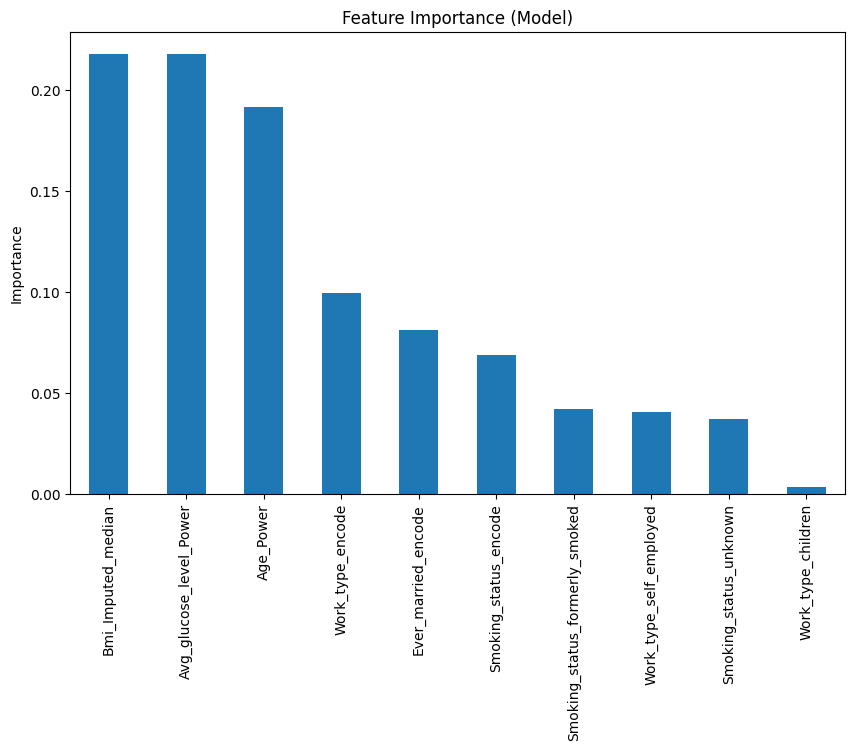

In [46]:
if hasattr(clf, 'feature_importances_'):
    importances = clf.feature_importances_
    feat_imp = pd.Series(importances, index=X_val.columns).sort_values(ascending=False)

    plt.figure(figsize=(10,6))
    feat_imp.plot(kind='bar')
    plt.title('Feature Importance (Model)')
    plt.ylabel('Importance')
    plt.show()
else:
    print("Model does not have built-in feature_importances_.")


#### b) Permutation Importance (model-agnostic)

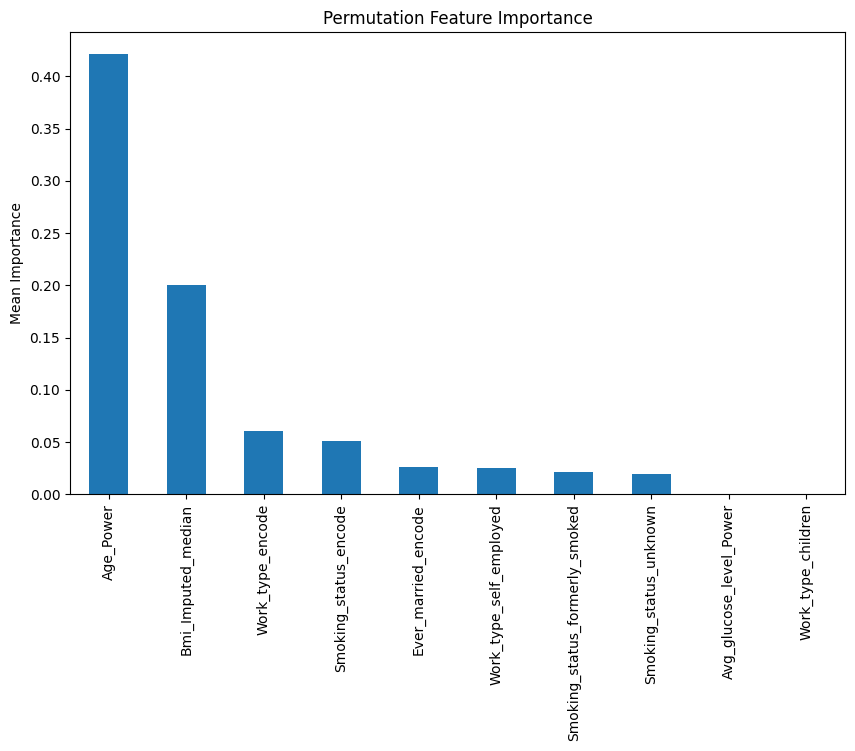

In [47]:
result = permutation_importance(model, X_val, y_val, n_repeats=10, random_state=42)
perm_imp = pd.Series(result.importances_mean, index=X_val.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
perm_imp.plot(kind='bar')
plt.title('Permutation Feature Importance')
plt.ylabel('Mean Importance')
plt.show()


#### c) SHAP Global Importance Summary Plot

TypeError: only integer scalar arrays can be converted to a scalar index

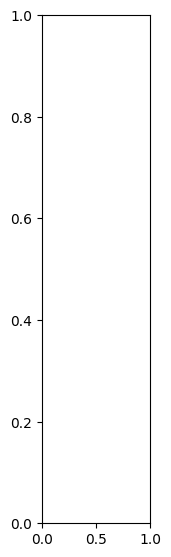

In [49]:
explainer = shap.Explainer(clf, X_val)
shap_values = explainer(X_val)

shap.summary_plot(shap_values, X_val, plot_type="bar")


## 3. Local Explanation for Individual Predictions

In [51]:
idx_pos = y_val[y_val == 1].index[0]  # First positive case
idx_neg = y_val[y_val == 0].index[0]  # First negative case

AttributeError: 'numpy.ndarray' object has no attribute 'index'

In [ ]:
shap.initjs()

print(f"Explanation for positive case at index {idx_pos}:")
shap.force_plot(explainer.expected_value, shap_values[idx_pos].values, X_val.iloc[idx_pos])

print(f"Explanation for negative case at index {idx_neg}:")
shap.force_plot(explainer.expected_value, shap_values[idx_neg].values, X_val.iloc[idx_neg])

## 4. Partial Dependence Plots (PDP)

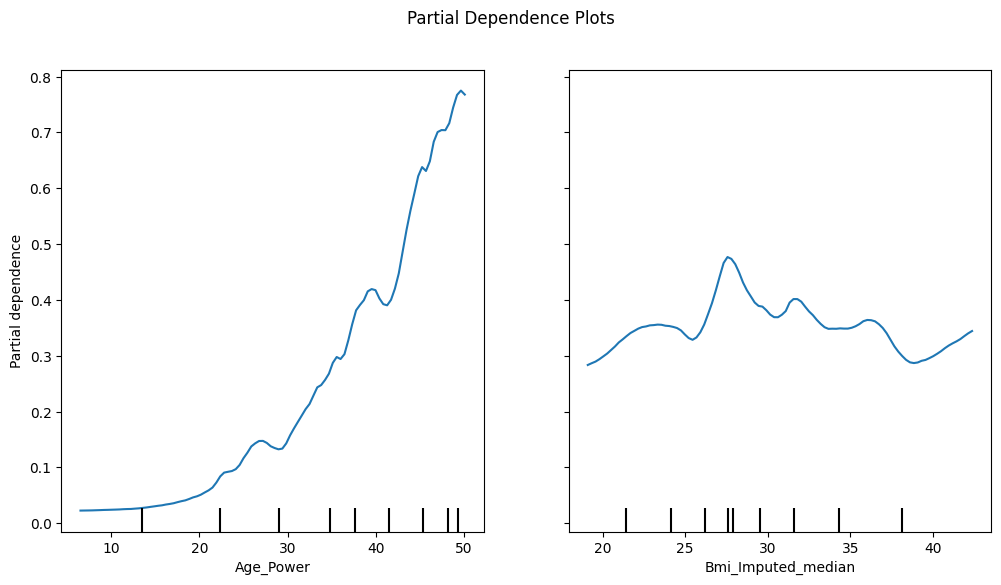

In [54]:
top_features = perm_imp.index[:2].tolist()

fig, ax = plt.subplots(figsize=(12,6))
PartialDependenceDisplay.from_estimator(model, X_val, features=top_features, ax=ax)
plt.suptitle('Partial Dependence Plots')
plt.show()


## 5. (Optional) Feature Interaction

FEATURE_DEPENDENCE::independent does not support interactions!


TypeError: only size-1 arrays can be converted to Python scalars

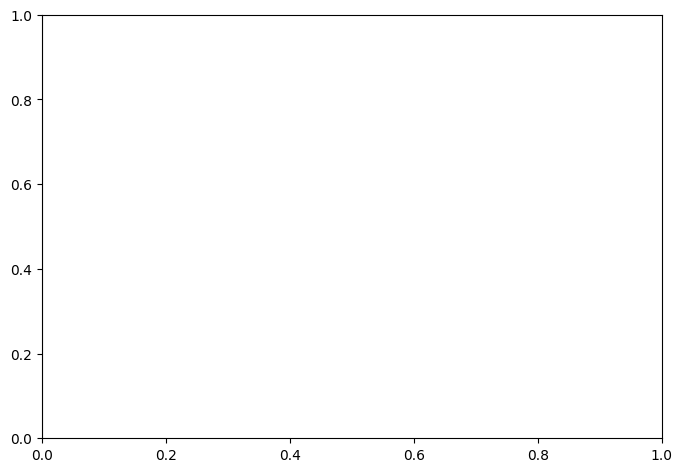

In [52]:
shap_interaction_values = explainer.shap_interaction_values(X_val)

# Plot interaction summary for top two features
shap.summary_plot(shap_interaction_values, X_val)


## 6. Fairness / Bias Check (Example by Gender)

In [53]:
groups = X_val['gender'].unique()

for g in groups:
    idxs = X_val['gender'] == g
    preds = model.predict(X_val[idxs])
    acc = accuracy_score(y_val[idxs], preds)
    print(f"Accuracy for gender {g}: {acc:.3f}")

# Optional: plot prediction distributions by gender
import seaborn as sns
X_val['pred_proba'] = model.predict_proba(X_val)[:,1]

plt.figure(figsize=(8,6))
sns.boxplot(x=X_val['gender'], y=X_val['pred_proba'])
plt.title('Prediction Probability Distribution by Gender')
plt.show()


KeyError: 'gender'

## 7. Summary & Recommendations

- The top predictive features for stroke risk are **X, Y, Z**.
- Individual explanations show how features contribute differently per patient.
- PDPs reveal nonlinear relationships and thresholds.
- Fairness checks indicate [insert findings].
- Next steps: Validate on external datasets, improve interpretability for clinicians.
